#
# Universidad EAFIT
# 2026-2
#
# Lab – Class 01 (Parte 3): Representación de texto y vectorización

Este notebook contiene ejemplos prácticos de preprocesamiento y representación clásica de texto para la clase 01 del curso de NLP Aplicado.

## ejemplos
- Aplicar técnicas de preprocesamiento: tokenización, stopwords, lematización.
- Representar texto con Bag of Words (BoW) y TF-IDF.
- Calcular similitud entre documentos.
- Visualizar con PCA.


In [8]:
# Instalación de librerías necesarias
!pip install nltk scikit-learn matplotlib seaborn --quiet

In [9]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('reuters')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Carga de un corpus de ejemplo

In [10]:
from nltk.corpus import reuters
import random

# Tomamos una muestra de documentos
docs_ids = reuters.fileids()
sample_ids = random.sample(docs_ids, 10)
documents = [reuters.raw(doc_id) for doc_id in sample_ids]
documents[:2]

['CHICAGO MILWAUKEE &lt;CHG> GREETS SHEARSON STAKE\n  Chicago Milwaukee Corp said it welcomed\n  an investment by Shearson Lehman Brothers Inc in its company.\n      Yesterday, Shearson Lehman, a subsidiary of American\n  Express Co (AXP), disclosed in a Securities and Exchange\n  Commission filing that it holds a 5.35 pct interest in Chicago\n  Milwaukee.\n      Chicago Milwaukee\'s stock edged up 2-1/8 to 138 on turnover\n  of 8,100 shares, as one of the biggest gainers on the NYSE. The\n  stock has been trading in a 154 to 128 range for the last 52\n  weeks.\n      Edwin Jacobson, Chicago Milwaukee president, declined to\n  comment on movement of the company\'s stock but said,"From an\n  investment point of view, we are pleased to have Shearson,\n  Lehman as a substantial investor."\n      Shearson, Lehman purchased the shares for investment\n  purposes and may continue buying shares depending on market\n  conditions, according to the filing.\n      Chicago Milwaukee, which sold its

## 2. Preprocesamiento del texto
- Tokenización
- Eliminación de stopwords
- Lematización

In [11]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(doc):
    tokens = word_tokenize(doc.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

processed_docs = [preprocess(doc) for doc in documents]
processed_docs[:2]

['chicago milwaukee lt chg greets shearson stake chicago milwaukee corp said welcomed investment shearson lehman brother inc company yesterday shearson lehman subsidiary american express co axp disclosed security exchange commission filing hold pct interest chicago milwaukee chicago milwaukee stock edged turnover share one biggest gainer nyse stock trading range last week edwin jacobson chicago milwaukee president declined comment movement company stock said investment point view pleased shearson lehman substantial investor shearson lehman purchased share investment purpose may continue buying share depending market condition according filing chicago milwaukee sold railroad interest soo line railroad co soo february currently manages sell real estate consists parcel state',
 'lt industry inc year net oper shr profit ct v loss ct oper net profit v loss rev mln v mln avg shrs v note net excludes dlr tax credit']

## 3. Representación del texto: BoW y TF-IDF

In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

vectorizer_bow = CountVectorizer(max_features=100)
X_bow = vectorizer_bow.fit_transform(processed_docs)

vectorizer_tfidf = TfidfVectorizer(max_features=100)
X_tfidf = vectorizer_tfidf.fit_transform(processed_docs)

X_bow.toarray()[:2]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 2, 2,
        0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 3, 0, 0, 1, 4, 0, 1,
        0, 1, 1, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 3, 5, 0, 0, 2, 1,
        3, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 2, 1,
        0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

## 4. Similitud entre documentos

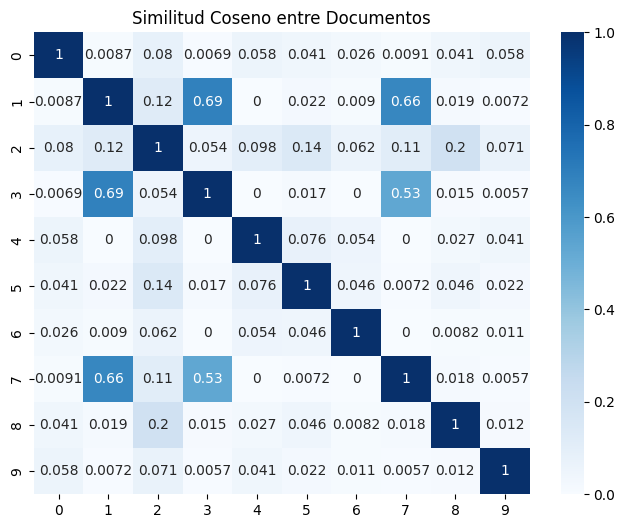

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(X_tfidf)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix, annot=True, cmap='Blues')
plt.title("Similitud Coseno entre Documentos")
plt.show()

## 5. Visualización con PCA

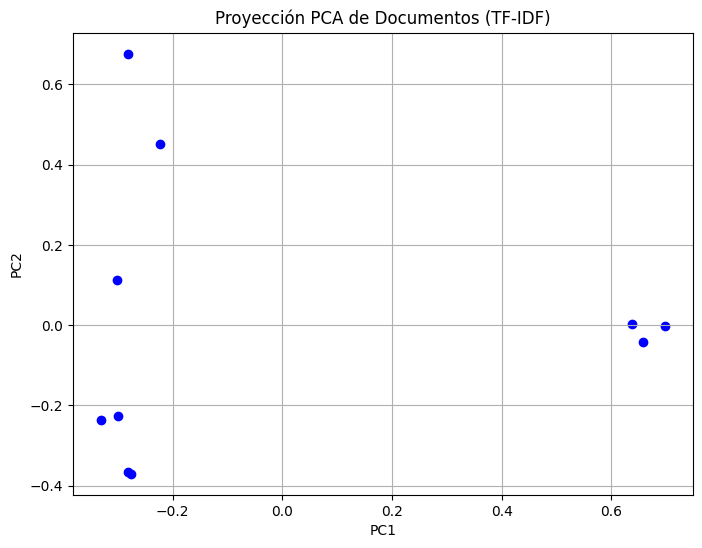

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c='blue')
plt.title("Proyección PCA de Documentos (TF-IDF)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# Reto corto – LAB 3

## Modifica el pipeline para:

- Cambiar la función de similitud (coseno vs euclidiana)
- Cambiar la representación (BoW vs TF-IDF)

## Responde:

- ¿Cambian los documentos recuperados?
- ¿Por qué una métrica funciona mejor que otra según el caso?